# Reproducing Figures 5a, 5b, and 8

From: *Insights Regarding the Success of Damping in Improving Belief Propagation*  
(Zivan, Zaed, Lev, 2025 — ARTINT-S-25-01089)

All figures use **3-variable single-cycle** factor graphs solved with **Damped Min-Sum (λ=0.9)**.

| Figure | Route type | Tail? | Lines plotted | Expected behavior |
|--------|-----------|-------|---------------|-------------------|
| 5a | Consistent minimal route | No | 3 (optimal value per variable) | All lines grow linearly with equal slopes |
| 5b | Consistent minimal route | Yes | 3 | Lines initially diverge, then converge to equal slopes |
| 8 | Inconsistent minimal route | No | 6 (two values per variable) | All 6 lines converge to the same slope |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product as cartesian_product

from propflow import (
    VariableAgent,
    FactorAgent,
    FactorGraph,
    DampingEngine,
    BPEngine,
    FGBuilder,
)

## Core helpers

In [2]:
def build_manual_cycle(ct_f12, ct_f23, ct_f31):
    """Build a 3-variable cycle from explicit 2D cost tables.
    
    Topology:  x1 --f12-- x2 --f23-- x3 --f31-- x1
    
    Each cost table is (domain x domain). For f_ij, row = x_i value, col = x_j value.
    """
    domain = ct_f12.shape[0]
    
    x1 = VariableAgent("x1", domain=domain)
    x2 = VariableAgent("x2", domain=domain)
    x3 = VariableAgent("x3", domain=domain)
    
    f12 = FactorAgent.create_from_cost_table("f12", np.array(ct_f12, dtype=float))
    f23 = FactorAgent.create_from_cost_table("f23", np.array(ct_f23, dtype=float))
    f31 = FactorAgent.create_from_cost_table("f31", np.array(ct_f31, dtype=float))
    
    variables = [x1, x2, x3]
    factors = [f12, f23, f31]
    edges = {
        f12: [x1, x2],
        f23: [x2, x3],
        f31: [x3, x1],
    }
    
    return FGBuilder.build_from_edges(variables, factors, edges)


def run_and_record(engine, max_iter, route_assignment):
    """Step-by-step execution, recording belief at route value minus initial.
    
    Plots belief(route_value) - belief(route_value, iter=0) for each variable.
    This makes all lines start at 0, matching the paper's convention.
    
    Args:
        engine: a BPEngine instance (already initialized)
        max_iter: number of iterations to run
        route_assignment: tuple (d1, d2, d3) — the consistent route values
    
    Returns:
        dict {var_name: list[float]} — one time series per variable
    """
    records = {f"x{i+1}": [] for i in range(3)}
    first = None
    
    for i in range(max_iter):
        engine.step(i)
        beliefs = engine.get_beliefs()
        raw = [float(beliefs[f"x{j+1}"][route_assignment[j]]) for j in range(3)]
        if first is None:
            first = raw[:]
        for j in range(3):
            records[f"x{j+1}"].append(raw[j] - first[j])
    
    return records


def run_and_record_canonical(engine, max_iter, route_assignment):
    """Same as run_and_record but with canonical keys for averaging."""
    records = {f"x{i+1}_route": [] for i in range(3)}
    first = None
    
    for i in range(max_iter):
        engine.step(i)
        beliefs = engine.get_beliefs()
        raw = [float(beliefs[f"x{j+1}"][route_assignment[j]]) for j in range(3)]
        if first is None:
            first = raw[:]
        for j in range(3):
            records[f"x{j+1}_route"].append(raw[j] - first[j])
    
    return records


def check_consistency(ct_f12, ct_f23, ct_f31):
    """Follow the argmin chain around the cycle to check for consistency.
    
    Returns (is_consistent, route_assignment_or_None).
    The route assignment is the tuple (x1, x2, x3) from the consistent route.
    """
    domain = ct_f12.shape[0]
    
    for x1_start in range(domain):
        x2 = int(np.argmin(ct_f12[x1_start, :]))
        x3 = int(np.argmin(ct_f23[x2, :]))
        x1_end = int(np.argmin(ct_f31[x3, :]))
        if x1_start == x1_end:
            return True, (x1_start, x2, x3)
    
    return False, None


def has_tail(ct_f12, ct_f23, ct_f31, domain=2, check_iters=5):
    """Check if undamped Min-Sum changes assignment after iteration 0.
    
    A 'tail' means the initial assignment differs from the converged one.
    """
    fg = build_manual_cycle(ct_f12, ct_f23, ct_f31)
    engine = BPEngine(factor_graph=fg, normalize_messages=False)
    
    assignments = []
    for i in range(check_iters):
        engine.step(i)
        assignments.append(tuple(engine.assignments[f"x{j+1}"] for j in range(3)))
    
    return any(assignments[k] != assignments[0] for k in range(1, len(assignments)))

## Generator: Figure 5a — Consistent minimal route, no tail

In [3]:
def generate_consistent_no_tail(seed, domain=2, low=0, high=10, max_attempts=5000):
    """Generate a random 3-variable cycle with consistent minimal route and no tail.
    
    Returns (fg, route_assignment) where route_assignment is from the consistent 
    argmin chain (what BP converges to), not the brute-force optimal.
    """
    rng = np.random.RandomState(seed)
    
    for attempt in range(max_attempts):
        ct_f12 = rng.randint(low, high, size=(domain, domain)).astype(float)
        ct_f23 = rng.randint(low, high, size=(domain, domain)).astype(float)
        ct_f31 = rng.randint(low, high, size=(domain, domain)).astype(float)
        
        is_consistent, route = check_consistency(ct_f12, ct_f23, ct_f31)
        if not is_consistent:
            continue
        
        # check no tail
        if has_tail(ct_f12, ct_f23, ct_f31, domain):
            continue
        
        fg = build_manual_cycle(ct_f12, ct_f23, ct_f31)
        return fg, route
    
    raise RuntimeError(f"No valid graph found after {max_attempts} attempts (consistent, no tail)")


# quick sanity check
fg_test, route_test = generate_consistent_no_tail(seed=42)
print(f"Route assignment: {route_test}")
for f in fg_test.factors:
    print(f"{f.name}: {f.cost_table}")

Route assignment: (1, 1, 1)
f12: [[7. 2.]
 [5. 4.]]
f23: [[1. 7.]
 [5. 1.]]
f31: [[4. 0.]
 [9. 5.]]


## Generator: Figure 5b — Consistent minimal route, with tail

In [4]:
def generate_consistent_with_tail(seed, domain=2, low=0, high=10, max_attempts=5000):
    """Generate a random 3-variable cycle with consistent minimal route and a tail.
    
    Returns (fg, route_assignment).
    """
    rng = np.random.RandomState(seed)
    
    for attempt in range(max_attempts):
        ct_f12 = rng.randint(low, high, size=(domain, domain)).astype(float)
        ct_f23 = rng.randint(low, high, size=(domain, domain)).astype(float)
        ct_f31 = rng.randint(low, high, size=(domain, domain)).astype(float)
        
        is_consistent, route = check_consistency(ct_f12, ct_f23, ct_f31)
        if not is_consistent:
            continue
        
        # check HAS tail
        if not has_tail(ct_f12, ct_f23, ct_f31, domain):
            continue
        
        fg = build_manual_cycle(ct_f12, ct_f23, ct_f31)
        return fg, route
    
    raise RuntimeError(f"No valid graph found after {max_attempts} attempts (consistent, with tail)")


# quick sanity check
fg_test, route_test = generate_consistent_with_tail(seed=42)
print(f"Route assignment: {route_test}")
for f in fg_test.factors:
    print(f"{f.name}: {f.cost_table}")

Route assignment: (1, 1, 0)
f12: [[6. 3.]
 [7. 4.]]
f23: [[6. 9.]
 [2. 6.]]
f31: [[7. 4.]
 [3. 7.]]


## Generator: Figure 8 — Inconsistent minimal route

In [5]:
def generate_inconsistent(seed, domain=2, low=0, high=10, max_attempts=5000):
    """Generate a random 3-variable cycle with inconsistent minimal route.
    
    Returns (fg, oscillating_values_dict) where oscillating_values_dict maps
    var_name -> [val_a, val_b] showing the two values that compete.
    """
    rng = np.random.RandomState(seed)
    
    for attempt in range(max_attempts):
        ct_f12 = rng.randint(low, high, size=(domain, domain)).astype(float)
        ct_f23 = rng.randint(low, high, size=(domain, domain)).astype(float)
        ct_f31 = rng.randint(low, high, size=(domain, domain)).astype(float)
        
        # check inconsistency
        is_consistent, routes = check_consistency(ct_f12, ct_f23, ct_f31)
        if is_consistent:
            continue
        
        # for domain=2, both values oscillate for each variable
        oscillating = {f"x{i+1}": list(range(domain)) for i in range(3)}
        
        fg = build_manual_cycle(ct_f12, ct_f23, ct_f31)
        return fg, oscillating
    
    raise RuntimeError(f"No valid graph found after {max_attempts} attempts (inconsistent)")


# quick sanity check
fg_test, osc_test = generate_inconsistent(seed=42)
print(f"Oscillating values: {osc_test}")
for f in fg_test.factors:
    print(f"{f.name}: {f.cost_table}")

Oscillating values: {'x1': [0, 1], 'x2': [0, 1], 'x3': [0, 1]}
f12: [[5. 2.]
 [0. 2.]]
f23: [[4. 2.]
 [0. 4.]]
f31: [[9. 6.]
 [6. 8.]]


## Plotting helpers

In [6]:
# paper-matching style: default matplotlib colors, solid lines, no markers, no grid
PAPER_COLORS = ["tab:blue", "tab:orange", "tab:green"]
PAPER_LABELS_3 = ["v1", "v2", "v3"]
# for figure 8 (6 lines): solid for value 0, dashed for value 1
PAPER_LABELS_6 = ["v1 (d=0)", "v1 (d=1)", "v2 (d=0)", "v2 (d=1)", "v3 (d=0)", "v3 (d=1)"]
PAPER_STYLES_6 = ["-", "--", "-", "--", "-", "--"]
PAPER_COLORS_6 = ["tab:blue", "tab:blue", "tab:orange", "tab:orange", "tab:green", "tab:green"]

# canonical keys for consistent figures
CONSISTENT_KEYS = ["x1_route", "x2_route", "x3_route"]
CONSISTENT_RAW_KEYS = ["x1", "x2", "x3"]
# canonical key ordering for inconsistent figure (6 lines)
INCONSISTENT_KEYS = ["x1_v0", "x1_v1", "x2_v0", "x2_v1", "x3_v0", "x3_v1"]


def plot_beliefs_paper(records, title, ax=None, mode="consistent"):
    """Plot belief trajectories matching the paper's style.
    
    mode: 'consistent' (3 lines, Figs 5a/5b) or 'inconsistent' (6 lines, Fig 8)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    
    if mode == "consistent":
        if CONSISTENT_KEYS[0] in records:
            keys = CONSISTENT_KEYS
        elif CONSISTENT_RAW_KEYS[0] in records:
            keys = CONSISTENT_RAW_KEYS
        else:
            keys = sorted(records.keys())
        for idx, key in enumerate(keys):
            ax.plot(records[key], color=PAPER_COLORS[idx], linestyle="-",
                    linewidth=1.8, label=PAPER_LABELS_3[idx])
    else:
        keys = INCONSISTENT_KEYS if INCONSISTENT_KEYS[0] in records else sorted(records.keys())
        for idx, key in enumerate(keys):
            ax.plot(records[key], color=PAPER_COLORS_6[idx],
                    linestyle=PAPER_STYLES_6[idx], linewidth=1.8,
                    label=PAPER_LABELS_6[idx])
    
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Value")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)
    return ax

## Averaged experiment runner

In [7]:
def compute_slopes(records, window_start, window_end):
    """Compute linear regression slopes for each tracked series in a window."""
    slopes = {}
    for key, values in records.items():
        y = np.array(values[window_start:window_end])
        x = np.arange(len(y))
        slopes[key] = np.polyfit(x, y, 1)[0]
    return slopes


def run_averaged_experiment(generator_fn, n_runs, max_iter, damping, title,
                            base_seed=0, ax=None, mode="consistent"):
    """Run multiple random instances and average belief trajectories.
    
    For consistent mode: records belief(route_value) - initial.
    For inconsistent mode: records raw beliefs - initial for all domain values.
    """
    all_records = []
    
    for run_idx in range(n_runs):
        seed = base_seed + run_idx * 1000
        try:
            fg, metadata = generator_fn(seed)
        except RuntimeError:
            continue
        
        engine = DampingEngine(
            factor_graph=fg,
            damping_factor=damping,
            normalize_messages=False,
        )
        
        if mode == "consistent":
            records = run_and_record_canonical(engine, max_iter, metadata)
        else:
            # inconsistent: track raw beliefs for all values, subtract initial
            records = {}
            first = {}
            for i in range(max_iter):
                engine.step(i)
                beliefs = engine.get_beliefs()
                for j in range(3):
                    var = f"x{j+1}"
                    for v in range(2):
                        key = f"x{j+1}_v{v}"
                        val = float(beliefs[var][v])
                        if key not in records:
                            records[key] = []
                            first[key] = val
                        records[key].append(val - first[key])
        
        all_records.append(records)
    
    print(f"  Successful runs: {len(all_records)}/{n_runs}")
    if not all_records:
        return None, None, None
    
    all_keys = list(all_records[0].keys())
    mean_records = {}
    std_records = {}
    for key in all_keys:
        series = [r[key] for r in all_records if key in r]
        arr = np.array(series)
        mean_records[key] = arr.mean(axis=0)
        std_records[key] = arr.std(axis=0)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    
    iterations = np.arange(max_iter)
    
    if mode == "consistent":
        key_order = CONSISTENT_KEYS if CONSISTENT_KEYS[0] in mean_records else all_keys
        labels = PAPER_LABELS_3
        colors = PAPER_COLORS
        styles = ["-"] * 3
    else:
        key_order = INCONSISTENT_KEYS if INCONSISTENT_KEYS[0] in mean_records else all_keys
        labels = PAPER_LABELS_6
        colors = PAPER_COLORS_6
        styles = PAPER_STYLES_6
    
    for idx, key in enumerate(key_order):
        mean = mean_records[key]
        std = std_records[key]
        ax.plot(iterations, mean, color=colors[idx], linestyle=styles[idx],
                linewidth=1.8, label=labels[idx])
        ax.fill_between(iterations, mean - std, mean + std,
                        color=colors[idx], alpha=0.15)
    
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Value")
    ax.set_title(f"{title} (n={len(all_records)})")
    ax.legend(loc="best", fontsize=9)
    
    return mean_records, std_records, all_keys

## Figure 5a: Consistent route, no tail

**Expected:** all 3 lines (one per variable's optimal value) grow linearly with equal slopes.

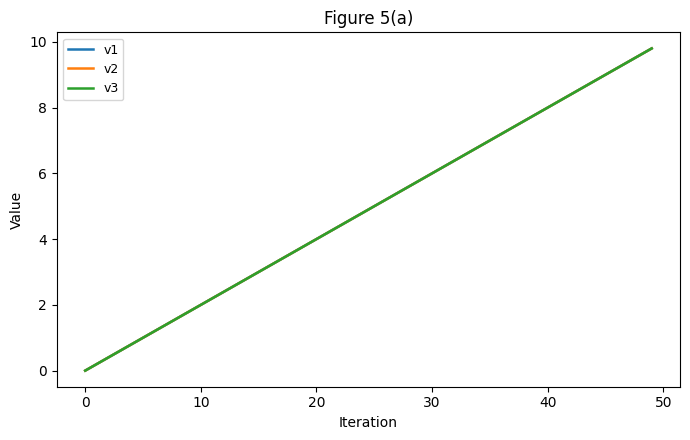

Route assignment: (0, 0, 0)
Single-instance slopes (last 20 iters):
  x1: 0.200000
  x2: 0.200000
  x3: 0.200000

Averaged over 20 runs (50 iterations each):
  Successful runs: 20/20


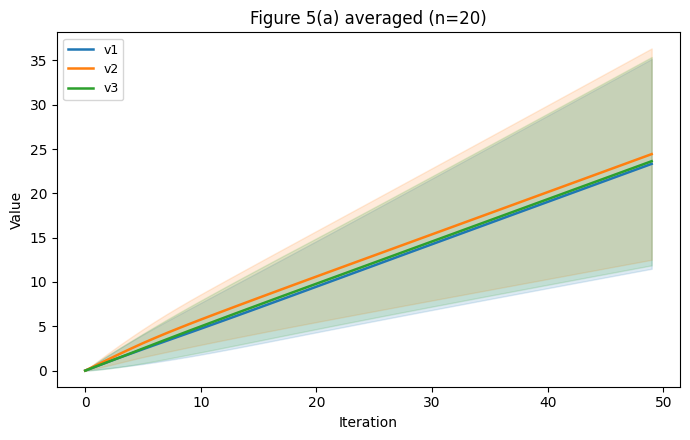

Averaged slopes (last 20 iters):
  x1_route: 0.477305
  x2_route: 0.476507
  x3_route: 0.476714
  Relative spread: 0.1674%


In [8]:
MAX_ITER = 50
DAMPING = 0.9
SLOPE_WINDOW = 20  # last N iterations for slope measurement

# --- single-instance plot (symmetric cost tables → all lines identical) ---
# using identical cost tables for all 3 factors gives perfect symmetry
ct_5a = np.array([[1., 5.], [5., 2.]])
fg_5a = build_manual_cycle(ct_5a, ct_5a, ct_5a)
route_5a = (0, 0, 0)  # consistent route for this table
engine_5a = DampingEngine(factor_graph=fg_5a, damping_factor=DAMPING, normalize_messages=False)
records_5a = run_and_record(engine_5a, MAX_ITER, route_5a)

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_beliefs_paper(records_5a, "Figure 5(a)", ax=ax, mode="consistent")
plt.tight_layout()
plt.show()

slopes_5a = compute_slopes(records_5a, MAX_ITER - SLOPE_WINDOW, MAX_ITER)
print(f"Route assignment: {route_5a}")
print("Single-instance slopes (last 20 iters):")
for key, slope in slopes_5a.items():
    print(f"  {key}: {slope:.6f}")

# --- averaged plot ---
print(f"\nAveraged over 20 runs ({MAX_ITER} iterations each):")
fig, ax = plt.subplots(figsize=(7, 4.5))
mean_5a, std_5a, keys_5a = run_averaged_experiment(
    generate_consistent_no_tail, n_runs=20, max_iter=MAX_ITER, damping=DAMPING,
    title="Figure 5(a) averaged",
    ax=ax, mode="consistent",
)
plt.tight_layout()
plt.show()

if mean_5a is not None:
    slopes = compute_slopes(mean_5a, MAX_ITER - SLOPE_WINDOW, MAX_ITER)
    print("Averaged slopes (last 20 iters):")
    for key, slope in slopes.items():
        print(f"  {key}: {slope:.6f}")
    vals = list(slopes.values())
    print(f"  Relative spread: {(max(vals) - min(vals)) / np.mean(vals) * 100:.4f}%")

## Figure 5b: Consistent route, with tail

**Expected:** lines initially diverge (some variables pick wrong values), then converge to equal slopes after the tail period. The paper plots a single instance.

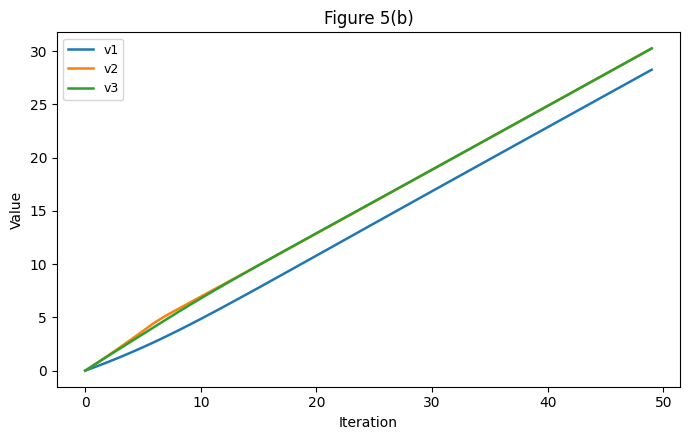

Route assignment: (1, 1, 0)
Single-instance slopes (last 20 iters):
  x1: 0.600585
  x2: 0.600033
  x3: 0.599382

Averaged over 20 runs (50 iterations each):
  Successful runs: 20/20


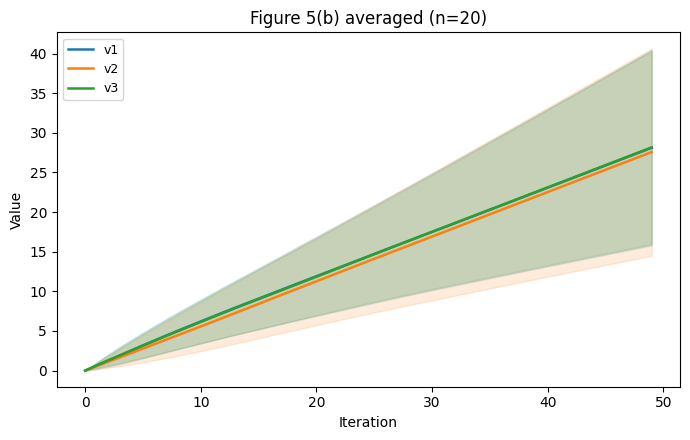

Averaged slopes (last 20 iters):
  x1_route: 0.558713
  x2_route: 0.561400
  x3_route: 0.560971
  Relative spread: 0.4795%


In [9]:
# --- single-instance plot ---
fg_5b, route_5b = generate_consistent_with_tail(seed=42)
engine_5b = DampingEngine(factor_graph=fg_5b, damping_factor=DAMPING, normalize_messages=False)
records_5b = run_and_record(engine_5b, MAX_ITER, route_5b)

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_beliefs_paper(records_5b, "Figure 5(b)", ax=ax, mode="consistent")
plt.tight_layout()
plt.show()

slopes_5b = compute_slopes(records_5b, MAX_ITER - SLOPE_WINDOW, MAX_ITER)
print(f"Route assignment: {route_5b}")
print("Single-instance slopes (last 20 iters):")
for key, slope in slopes_5b.items():
    print(f"  {key}: {slope:.6f}")

# --- averaged plot ---
print(f"\nAveraged over 20 runs ({MAX_ITER} iterations each):")
fig, ax = plt.subplots(figsize=(7, 4.5))
mean_5b, std_5b, keys_5b = run_averaged_experiment(
    generate_consistent_with_tail, n_runs=20, max_iter=MAX_ITER, damping=DAMPING,
    title="Figure 5(b) averaged",
    ax=ax, mode="consistent",
)
plt.tight_layout()
plt.show()

if mean_5b is not None:
    slopes = compute_slopes(mean_5b, MAX_ITER - SLOPE_WINDOW, MAX_ITER)
    print("Averaged slopes (last 20 iters):")
    for key, slope in slopes.items():
        print(f"  {key}: {slope:.6f}")
    vals = list(slopes.values())
    print(f"  Relative spread: {(max(vals) - min(vals)) / np.mean(vals) * 100:.4f}%")

## Figure 8: Inconsistent minimal route

**Expected:** all 6 lines (two values per variable) converge to the same slope. The paper plots a single instance.

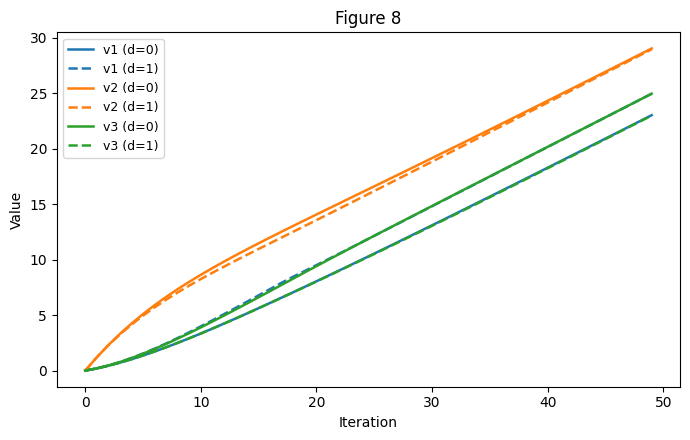

Single-instance slopes (last 20 iters):
  x1_v0: 0.522658
  x1_v1: 0.534036
  x2_v0: 0.520463
  x2_v1: 0.533099
  x3_v0: 0.532866
  x3_v1: 0.523568
  Relative spread: 2.5715%

Averaged over 20 runs (50 iterations each):
  Successful runs: 20/20


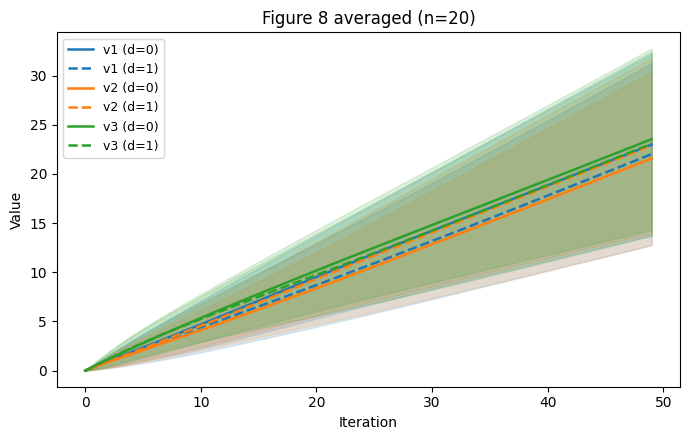

Averaged slopes (last 20 iters):
  x1_v0: 0.460903
  x1_v1: 0.465492
  x2_v0: 0.459218
  x2_v1: 0.465993
  x3_v0: 0.459350
  x3_v1: 0.465457
  Relative spread: 1.4643%


In [10]:
# --- single-instance plot ---
fg_8, osc_8 = generate_inconsistent(seed=42)
engine_8 = DampingEngine(factor_graph=fg_8, damping_factor=DAMPING, normalize_messages=False)

# track raw beliefs for all values, subtract initial
records_8 = {}
first_8 = {}
for i in range(MAX_ITER):
    engine_8.step(i)
    beliefs = engine_8.get_beliefs()
    for j in range(3):
        var = f"x{j+1}"
        for v in range(2):
            key = f"x{j+1}_v{v}"
            val = float(beliefs[var][v])
            if key not in records_8:
                records_8[key] = []
                first_8[key] = val
            records_8[key].append(val - first_8[key])

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_beliefs_paper(records_8, "Figure 8", ax=ax, mode="inconsistent")
plt.tight_layout()
plt.show()

slopes_8 = compute_slopes(records_8, MAX_ITER - SLOPE_WINDOW, MAX_ITER)
print("Single-instance slopes (last 20 iters):")
for key, slope in slopes_8.items():
    print(f"  {key}: {slope:.6f}")
vals = list(slopes_8.values())
print(f"  Relative spread: {(max(vals) - min(vals)) / np.mean(vals) * 100:.4f}%")

# --- averaged plot ---
print(f"\nAveraged over 20 runs ({MAX_ITER} iterations each):")
fig, ax = plt.subplots(figsize=(7, 4.5))
mean_8, std_8, keys_8 = run_averaged_experiment(
    generate_inconsistent, n_runs=20, max_iter=MAX_ITER, damping=DAMPING,
    title="Figure 8 averaged",
    ax=ax, mode="inconsistent",
)
plt.tight_layout()
plt.show()

if mean_8 is not None:
    slopes = compute_slopes(mean_8, MAX_ITER - SLOPE_WINDOW, MAX_ITER)
    print("Averaged slopes (last 20 iters):")
    for key, slope in slopes.items():
        print(f"  {key}: {slope:.6f}")
    vals = list(slopes.values())
    print(f"  Relative spread: {(max(vals) - min(vals)) / np.mean(vals) * 100:.4f}%")

## Summary: All three figures side by side

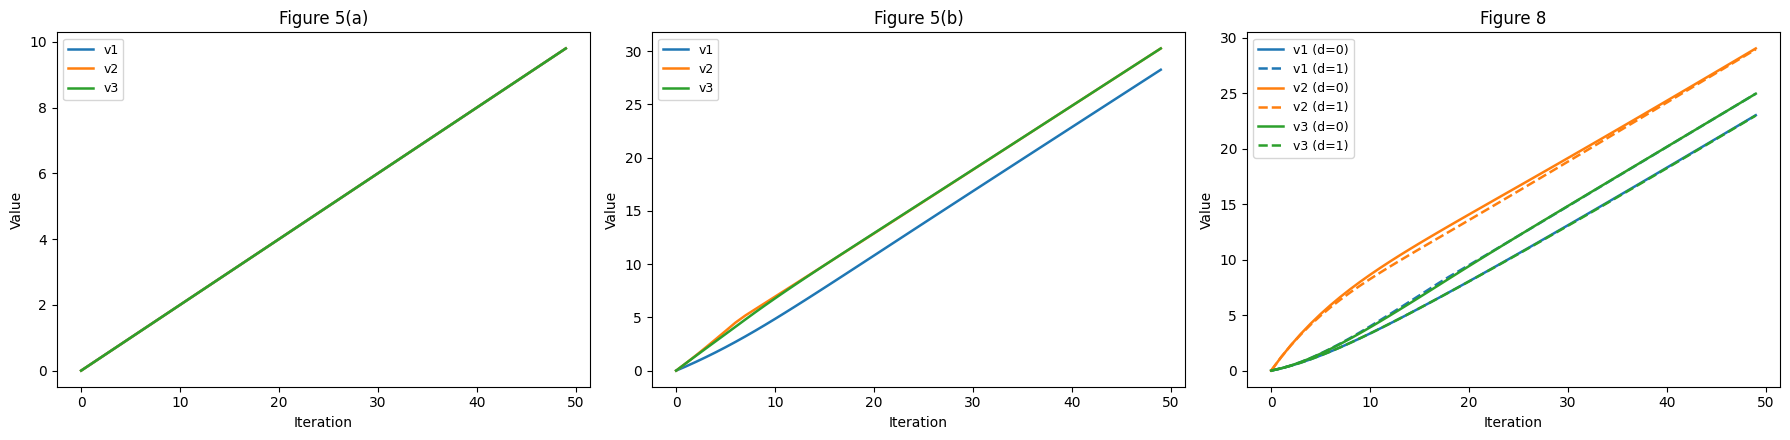

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

plot_beliefs_paper(records_5a, "Figure 5(a)", ax=axes[0], mode="consistent")
plot_beliefs_paper(records_5b, "Figure 5(b)", ax=axes[1], mode="consistent")
plot_beliefs_paper(records_8, "Figure 8", ax=axes[2], mode="inconsistent")

plt.tight_layout()
plt.show()

## Generator hit-rate analysis

How many random cost tables satisfy each constraint?

In [12]:
n_samples = 1000
rng = np.random.RandomState(99)
domain = 2

counts = {"consistent_no_tail": 0, "consistent_with_tail": 0, "inconsistent": 0}

for _ in range(n_samples):
    ct12 = rng.randint(0, 10, size=(domain, domain)).astype(float)
    ct23 = rng.randint(0, 10, size=(domain, domain)).astype(float)
    ct31 = rng.randint(0, 10, size=(domain, domain)).astype(float)
    
    is_consistent, _ = check_consistency(ct12, ct23, ct31)
    
    if not is_consistent:
        counts["inconsistent"] += 1
    else:
        tail = has_tail(ct12, ct23, ct31, domain)
        if tail:
            counts["consistent_with_tail"] += 1
        else:
            counts["consistent_no_tail"] += 1

print(f"Hit rates out of {n_samples} random graphs (domain={domain}):")
for category, count in counts.items():
    print(f"  {category}: {count} ({count/n_samples*100:.1f}%)")

Hit rates out of 1000 random graphs (domain=2):
  consistent_no_tail: 588 (58.8%)
  consistent_with_tail: 350 (35.0%)
  inconsistent: 62 (6.2%)
